In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.over_sampling import SMOTE
import mlflow
from churn_prediction.utils.mlflow_config import configure_mlflow
import warnings
warnings.filterwarnings('ignore')

In [56]:
# Load and preprocess data
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Handle TotalCharges - convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['Churn'].value_counts())

Dataset shape: (7043, 21)

Class distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [57]:
# Define features and target
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = ['TechSupport', 'Contract', 'Partner', 'OnlineSecurity', 'InternetService']

X = df[numeric_features + categorical_features]
y_raw = df['Churn']

# Encode target
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y_raw)

# Split data FIRST (before any transformations)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training: {X_train.shape}, Test: {X_test.shape}")

Training: (4930, 8), Test: (2113, 8)


In [58]:
# Create preprocessor (ColumnTransformer)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ]
)

In [59]:
xTrain = preprocessor.fit_transform(X_train)
xTest = preprocessor.transform(X_test)

In [60]:
sm = SMOTE(random_state=42)

xTrainRes, yTrainRes  = sm.fit_resample(xTrain, y_train)

print("After SMOTE")
print(f"Class 1: {sum(yTrainRes == 1)}")
print(f"Class 0: {sum(yTrainRes == 0)}")

After SMOTE
Class 1: 3622
Class 0: 3622


In [61]:
# Helper function to evaluate and log metrics
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred
    
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba)
    }
    
    print(f"{model_name}:")
    print(f"  Accuracy: {metrics['accuracy']:.4f}, Precision: {metrics['precision']:.4f}, Recall: {metrics['recall']:.4f}, F1: {metrics['f1_score']:.4f}, ROC-AUC: {metrics['roc_auc']:.4f}")
    
    return metrics

In [32]:
# ============================================
# EXPERIMENT 1: Classic ML Algorithms
# ============================================
print("=" * 60)
print("EXPERIMENT 1: Classic ML Algorithms")
print("=" * 60)

# Configure MLflow for Experiment 1
configure_mlflow("EXPERIMENT 1: Classic ML Algorithms")

# Define classic ML models - all use preprocessed SMOTE data
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

best_model = None
best_score = 0
best_model_name = ""

# Train and log each model
for model_name, model in models.items():
    with mlflow.start_run(run_name=model_name):
        mlflow.log_param("model", model_name)
        
        # Train on preprocessed + SMOTE data
        model.fit(xTrainRes, yTrainRes)
        
        # Evaluate on preprocessed test data
        y_pred = model.predict(xTest)
        y_proba = model.predict_proba(xTest)[:, 1] if hasattr(model, 'predict_proba') else y_pred
        
        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred),
            'recall': recall_score(y_test, y_pred),
            'f1_score': f1_score(y_test, y_pred),
            'roc_auc': roc_auc_score(y_test, y_proba)
        }
        
        print(f"{model_name}:")
        print(f"  Accuracy: {metrics['accuracy']:.4f}, Precision: {metrics['precision']:.4f}, Recall: {metrics['recall']:.4f}, F1: {metrics['f1_score']:.4f}, ROC-AUC: {metrics['roc_auc']:.4f}")
        
        # Log metrics to MLflow
        for metric_name, value in metrics.items():
            mlflow.log_metric(metric_name, value)
        
        # Track best model
        if metrics['f1_score'] > best_score:
            best_score = metrics['f1_score']
            best_model = model
            best_model_name = model_name
            best_metrics = metrics

print(f"\nBest Classic ML Model: {best_model_name} (F1: {best_score:.4f})")

EXPERIMENT 1: Classic ML Algorithms


2026/03/28 18:13:50 INFO mlflow.tracking.fluent: Experiment with name 'EXPERIMENT 1: Classic ML Algorithms' does not exist. Creating a new experiment.


Mlflow -> Dagshub | Experiment: EXPERIMENT 1: Classic ML Algorithms
Logistic Regression:
  Accuracy: 0.7302, Precision: 0.4950, Recall: 0.7914, F1: 0.6091, ROC-AUC: 0.8399
🏃 View run Logistic Regression at: https://dagshub.com/HimmatMagar/customer_churn_prediction.mlflow/#/experiments/1/runs/d0e574e54f4b412888efde85fbbca9bb
🧪 View experiment at: https://dagshub.com/HimmatMagar/customer_churn_prediction.mlflow/#/experiments/1
SVM:
  Accuracy: 0.7501, Precision: 0.5195, Recall: 0.7843, F1: 0.6250, ROC-AUC: 0.8154
🏃 View run SVM at: https://dagshub.com/HimmatMagar/customer_churn_prediction.mlflow/#/experiments/1/runs/433e3c90fc5e4825b7468833cb9cfd5d
🧪 View experiment at: https://dagshub.com/HimmatMagar/customer_churn_prediction.mlflow/#/experiments/1
KNN:
  Accuracy: 0.7265, Precision: 0.4893, Recall: 0.6934, F1: 0.5737, ROC-AUC: 0.7766
🏃 View run KNN at: https://dagshub.com/HimmatMagar/customer_churn_prediction.mlflow/#/experiments/1/runs/6009576da4884a3c86a1eba807665d25
🧪 View experimen

In [45]:
# ============================================
# EXPERIMENT 2: Ensemble Learning Algorithms
# ============================================
print("=" * 60)
print("EXPERIMENT 2: Ensemble Learning Algorithms")
print("=" * 60)

from xgboost import XGBClassifier

# Configure MLflow for Experiment 2
configure_mlflow("EXPERIMENT 2: Ensemble Learning Algorithm")

# Define ensemble models - all use preprocessed SMOTE data
ensemble_models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

best_ensemble_model = None
best_ensemble_score = 0
best_ensemble_name = ""

# Train and log each ensemble model
for model_name, model in ensemble_models.items():
    with mlflow.start_run(run_name=model_name):
        mlflow.log_param("model", model_name)
        
        # Train on preprocessed + SMOTE data
        model.fit(xTrainRes, yTrainRes)
        
        # Evaluate on preprocessed test data
        y_pred = model.predict(xTest)
        y_proba = model.predict_proba(xTest)[:, 1]
        
        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred),
            'recall': recall_score(y_test, y_pred),
            'f1_score': f1_score(y_test, y_pred),
            'roc_auc': roc_auc_score(y_test, y_proba)
        }
        
        print(f"{model_name}:")
        print(f"  Accuracy: {metrics['accuracy']:.4f}, Precision: {metrics['precision']:.4f}, Recall: {metrics['recall']:.4f}, F1: {metrics['f1_score']:.4f}, ROC-AUC: {metrics['roc_auc']:.4f}")
        
        # Log metrics to MLflow
        for metric_name, value in metrics.items():
            mlflow.log_metric(metric_name, value)
        
        # Log model-specific parameters
        if hasattr(model, 'n_estimators'):
            mlflow.log_param("n_estimators", model.n_estimators)
        
        # Track best ensemble model
        if metrics['f1_score'] > best_ensemble_score:
            best_ensemble_score = metrics['f1_score']
            best_ensemble_model = model
            best_ensemble_name = model_name
            best_ensemble_metrics = metrics

print(f"\nBest Ensemble Model: {best_ensemble_name} (F1: {best_ensemble_score:.4f})")

EXPERIMENT 2: Ensemble Learning Algorithms


2026/03/28 18:20:33 INFO mlflow.tracking.fluent: Experiment with name 'EXPERIMENT 2: Ensemble Learning Algorithm' does not exist. Creating a new experiment.


Mlflow -> Dagshub | Experiment: EXPERIMENT 2: Ensemble Learning Algorithm
Random Forest:
  Accuracy: 0.7582, Precision: 0.5396, Recall: 0.6078, F1: 0.5717, ROC-AUC: 0.7980
🏃 View run Random Forest at: https://dagshub.com/HimmatMagar/customer_churn_prediction.mlflow/#/experiments/4/runs/540800987b744d5da12331b523b0f410
🧪 View experiment at: https://dagshub.com/HimmatMagar/customer_churn_prediction.mlflow/#/experiments/4
Gradient Boosting:
  Accuracy: 0.7482, Precision: 0.5170, Recall: 0.7861, F1: 0.6238, ROC-AUC: 0.8360
🏃 View run Gradient Boosting at: https://dagshub.com/HimmatMagar/customer_churn_prediction.mlflow/#/experiments/4/runs/11f4a1cde1c54c0c8c28542dc51b83a8
🧪 View experiment at: https://dagshub.com/HimmatMagar/customer_churn_prediction.mlflow/#/experiments/4
XGBoost:
  Accuracy: 0.7449, Precision: 0.5146, Recall: 0.6934, F1: 0.5907, ROC-AUC: 0.8136
🏃 View run XGBoost at: https://dagshub.com/HimmatMagar/customer_churn_prediction.mlflow/#/experiments/4/runs/d5870904716e4819bc6

In [46]:
# ============================================
# EXPERIMENT 3: Hyperparameter Tuning with GridSearchCV
# ============================================
print("=" * 60)
print("EXPERIMENT 3: Chosseing Best Model")
print("=" * 60)

configure_mlflow("EXPERIMENT 3: SVM vs Gredient Boosting")

# Define ensemble models - all use preprocessed SMOTE data
ensemble_models = {
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

best_ensemble_model = None
best_ensemble_score = 0
best_ensemble_name = ""

# Train and log each ensemble model
for model_name, model in ensemble_models.items():
    with mlflow.start_run(run_name=model_name):
        mlflow.log_param("model", model_name)
        
        # Train on preprocessed + SMOTE data
        model.fit(xTrainRes, yTrainRes)
        
        # Evaluate on preprocessed test data
        y_pred = model.predict(xTest)
        y_proba = model.predict_proba(xTest)[:, 1]
        
        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred),
            'recall': recall_score(y_test, y_pred),
            'f1_score': f1_score(y_test, y_pred),
            'roc_auc': roc_auc_score(y_test, y_proba)
        }
        
        print(f"{model_name}:")
        print(f"  Accuracy: {metrics['accuracy']:.4f}, Precision: {metrics['precision']:.4f}, Recall: {metrics['recall']:.4f}, F1: {metrics['f1_score']:.4f}, ROC-AUC: {metrics['roc_auc']:.4f}")
        
        # Log metrics to MLflow
        for metric_name, value in metrics.items():
            mlflow.log_metric(metric_name, value)
        
        # Log model-specific parameters
        if hasattr(model, 'n_estimators'):
            mlflow.log_param("n_estimators", model.n_estimators)
        
        # Track best ensemble model
        if metrics['f1_score'] > best_ensemble_score:
            best_ensemble_score = metrics['f1_score']
            best_ensemble_model = model
            best_ensemble_name = model_name
            best_ensemble_metrics = metrics

print(f"\nBest Ensemble Model: {best_ensemble_name} (F1: {best_ensemble_score:.4f})")

EXPERIMENT 3: Chosseing Best Model


2026/03/28 18:22:58 INFO mlflow.tracking.fluent: Experiment with name 'EXPERIMENT 3: SVM vs Gredient Boosting' does not exist. Creating a new experiment.


Mlflow -> Dagshub | Experiment: EXPERIMENT 3: SVM vs Gredient Boosting
SVM:
  Accuracy: 0.7501, Precision: 0.5195, Recall: 0.7843, F1: 0.6250, ROC-AUC: 0.8154
🏃 View run SVM at: https://dagshub.com/HimmatMagar/customer_churn_prediction.mlflow/#/experiments/5/runs/335e368e94c2495ca48b7e14d2e8b758
🧪 View experiment at: https://dagshub.com/HimmatMagar/customer_churn_prediction.mlflow/#/experiments/5
Gradient Boosting:
  Accuracy: 0.7482, Precision: 0.5170, Recall: 0.7861, F1: 0.6238, ROC-AUC: 0.8360
🏃 View run Gradient Boosting at: https://dagshub.com/HimmatMagar/customer_churn_prediction.mlflow/#/experiments/5/runs/38eef281273e42c992821d333be316d5
🧪 View experiment at: https://dagshub.com/HimmatMagar/customer_churn_prediction.mlflow/#/experiments/5

Best Ensemble Model: SVM (F1: 0.6250)


EXPERIMENT 4: Hyperparameter Tuning (SVM & Gradient Boosting)
Mlflow -> Dagshub | Experiment: Customer_Churn_Hyperparameter_Tuning

4.1: Tuning SVM Hyperparameters
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Tuned SVM:
  Best Params: {'C': 10, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}
  CV Score: 0.7767
  Test Metrics: Accuracy=0.7534, F1=0.6254, ROC-AUC=0.8095
  Confusion Matrix:
[[1157  395]
 [ 126  435]]
🏃 View run SVM_Hyperparameter_Tuning at: https://dagshub.com/HimmatMagar/customer_churn_prediction.mlflow/#/experiments/6/runs/b2adc8a6473f4025aaaee8ddf1f9e67b
🧪 View experiment at: https://dagshub.com/HimmatMagar/customer_churn_prediction.mlflow/#/experiments/6

4.2: Tuning Gradient Boosting Hyperparameters
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Tuned Gradient Boosting:
  Best Params: {'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
  CV Score: 0.8189
  Test Met

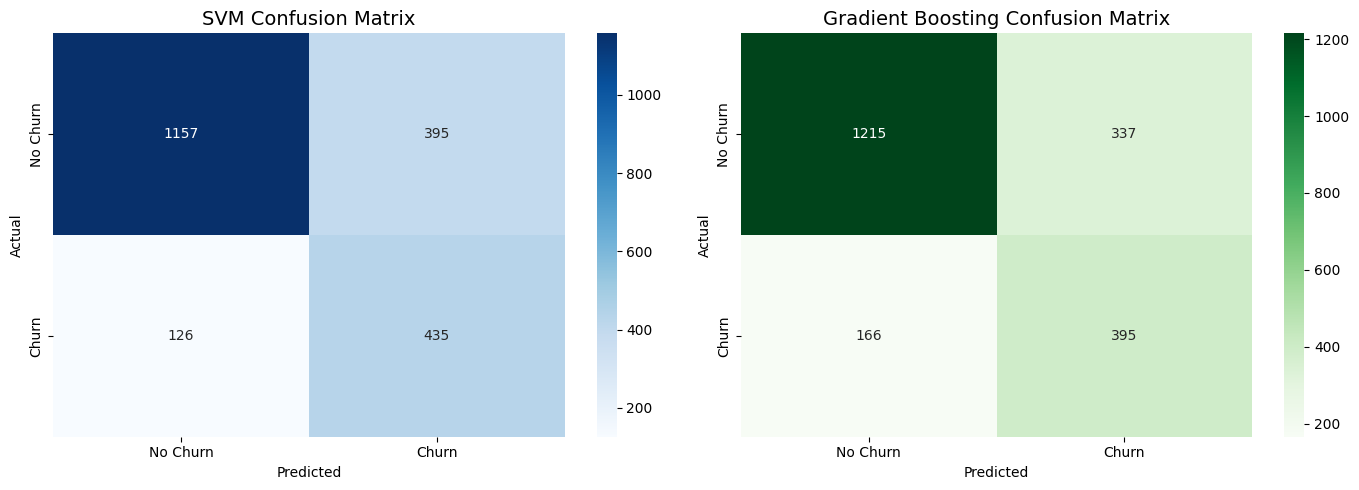


EXPERIMENT 4 COMPLETED - Model Comparison

Best Model: SVM
  F1 Score: 0.6254
  Best Parameters: {'C': 10, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}
🏃 View run Best_Model_Comparison at: https://dagshub.com/HimmatMagar/customer_churn_prediction.mlflow/#/experiments/6/runs/27312e6a626e48f7a57cac27438995bf
🧪 View experiment at: https://dagshub.com/HimmatMagar/customer_churn_prediction.mlflow/#/experiments/6


In [62]:
# ============================================
# EXPERIMENT 4: Hyperparameter Tuning with GridSearchCV
# ============================================
print("=" * 60)
print("EXPERIMENT 4: Hyperparameter Tuning (SVM & Gradient Boosting)")
print("=" * 60)

# Configure MLflow for Experiment 4
configure_mlflow("Customer_Churn_Hyperparameter_Tuning")

# Based on previous experiments, SVM and Gradient Boosting performed best
# Now we'll tune both to find the optimal model

# ============================================
# 4.1: Tune SVM Hyperparameters
# ============================================
print("\n" + "=" * 40)
print("4.1: Tuning SVM Hyperparameters")
print("=" * 40)

svm_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto'],
    'class_weight': ['balanced']
}

svm_grid_search = GridSearchCV(
    SVC(probability=True, random_state=42),
    svm_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

with mlflow.start_run(run_name="SVM_Hyperparameter_Tuning"):
    mlflow.log_param("model", "SVM")
    mlflow.log_param("cv_folds", 5)
    mlflow.log_param("scoring_metric", "f1")
    
    # Fit grid search
    svm_grid_search.fit(xTrainRes, yTrainRes)
    
    # Log best parameters
    svm_best_params = svm_grid_search.best_params_
    for param, value in svm_best_params.items():
        mlflow.log_param(f"svm_{param}", value)
    
    # Evaluate best SVM model
    svm_best_model = svm_grid_search.best_estimator_
    y_pred_svm = svm_best_model.predict(xTest)
    y_proba_svm = svm_best_model.predict_proba(xTest)[:, 1]
    
    svm_metrics = {
        'accuracy': accuracy_score(y_test, y_pred_svm),
        'precision': precision_score(y_test, y_pred_svm),
        'recall': recall_score(y_test, y_pred_svm),
        'f1_score': f1_score(y_test, y_pred_svm),
        'roc_auc': roc_auc_score(y_test, y_proba_svm)
    }
    
    # Confusion Matrix for SVM
    cm_svm = confusion_matrix(y_test, y_pred_svm)
    
    print(f"\nTuned SVM:")
    print(f"  Best Params: {svm_best_params}")
    print(f"  CV Score: {svm_grid_search.best_score_:.4f}")
    print(f"  Test Metrics: Accuracy={svm_metrics['accuracy']:.4f}, F1={svm_metrics['f1_score']:.4f}, ROC-AUC={svm_metrics['roc_auc']:.4f}")
    print(f"  Confusion Matrix:\n{cm_svm}")
    
    # Log metrics
    for metric_name, value in svm_metrics.items():
        mlflow.log_metric(f"svm_{metric_name}", value)
    mlflow.log_metric("svm_best_cv_score", svm_grid_search.best_score_)

# ============================================
# 4.2: Tune Gradient Boosting Hyperparameters
# ============================================
print("\n" + "=" * 40)
print("4.2: Tuning Gradient Boosting Hyperparameters")
print("=" * 40)

gb_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

gb_grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

with mlflow.start_run(run_name="GradientBoosting_Hyperparameter_Tuning"):
    mlflow.log_param("model", "GradientBoosting")
    mlflow.log_param("cv_folds", 5)
    mlflow.log_param("scoring_metric", "f1")
    
    # Fit grid search
    gb_grid_search.fit(xTrainRes, yTrainRes)
    
    # Log best parameters
    gb_best_params = gb_grid_search.best_params_
    for param, value in gb_best_params.items():
        mlflow.log_param(f"gb_{param}", value)
    
    # Evaluate best GB model
    gb_best_model = gb_grid_search.best_estimator_
    y_pred_gb = gb_best_model.predict(xTest)
    y_proba_gb = gb_best_model.predict_proba(xTest)[:, 1]
    
    gb_metrics = {
        'accuracy': accuracy_score(y_test, y_pred_gb),
        'precision': precision_score(y_test, y_pred_gb),
        'recall': recall_score(y_test, y_pred_gb),
        'f1_score': f1_score(y_test, y_pred_gb),
        'roc_auc': roc_auc_score(y_test, y_proba_gb)
    }
    
    # Confusion Matrix for Gradient Boosting
    cm_gb = confusion_matrix(y_test, y_pred_gb)
    
    print(f"\nTuned Gradient Boosting:")
    print(f"  Best Params: {gb_best_params}")
    print(f"  CV Score: {gb_grid_search.best_score_:.4f}")
    print(f"  Test Metrics: Accuracy={gb_metrics['accuracy']:.4f}, F1={gb_metrics['f1_score']:.4f}, ROC-AUC={gb_metrics['roc_auc']:.4f}")
    print(f"  Confusion Matrix:\n{cm_gb}")
    
    # Log metrics
    for metric_name, value in gb_metrics.items():
        mlflow.log_metric(f"gb_{metric_name}", value)
    mlflow.log_metric("gb_best_cv_score", gb_grid_search.best_score_)

# ============================================
# Confusion Matrix Visualization
# ============================================
print("\n" + "=" * 40)
print("Confusion Matrix Comparison")
print("=" * 40)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SVM Confusion Matrix
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[0].set_title('SVM Confusion Matrix', fontsize=14)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Gradient Boosting Confusion Matrix
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[1].set_title('Gradient Boosting Confusion Matrix', fontsize=14)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# ============================================
# Compare and Select Best Model
# ============================================
print("\n" + "=" * 60)
print("EXPERIMENT 4 COMPLETED - Model Comparison")
print("=" * 60)

if svm_metrics['f1_score'] > gb_metrics['f1_score']:
    best_model = svm_best_model
    best_model_name = "SVM"
    best_f1 = svm_metrics['f1_score']
    best_params = svm_best_params
else:
    best_model = gb_best_model
    best_model_name = "Gradient Boosting"
    best_f1 = gb_metrics['f1_score']
    best_params = gb_best_params

print(f"\nBest Model: {best_model_name}")
print(f"  F1 Score: {best_f1:.4f}")
print(f"  Best Parameters: {best_params}")

# Log final comparison to MLflow
with mlflow.start_run(run_name="Best_Model_Comparison"):
    mlflow.log_param("best_model", best_model_name)
    mlflow.log_param("best_parameters", best_params)
    mlflow.log_metric("best_f1_score", best_f1)
    mlflow.log_metric("svm_f1_score", svm_metrics['f1_score'])
    mlflow.log_metric("gb_f1_score", gb_metrics['f1_score'])